<a href="https://colab.research.google.com/github/Thilina93Gunasekara/it5437_assignment_02_258774L/blob/main/it5437_assignment_02_258774L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Q1a**

  Total Least Squares — Line 1 Results
  Normal vector : a = 0.773562,  b = -0.633721
  Offset        : c = -3.794192
  Line equation : 0.7736·x + -0.6337·y + -3.7942 = 0
  Slope-intercept: y = 1.2207·x + (-5.9872)


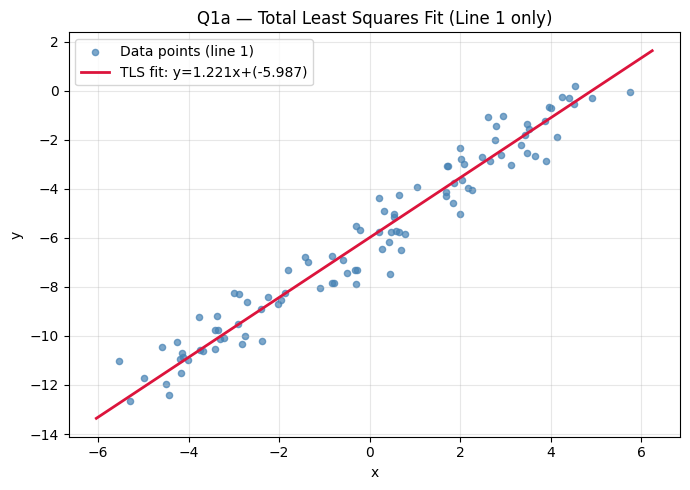

Plot saved as q1a_tls_line1.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load data
D = np.genfromtxt("/content/Assignment 2/lines.csv", delimiter=",", skip_header=1)

# Columns: x1, x2, x3, y1, y2, y3
X_cols = D[:, :3]   # columns 0,1,2 → x1, x2, x3
Y_cols = D[:, 3:]   # columns 3,4,5 → y1, y2, y3

# 2. Extract ONLY the first line's data (x1, y1)
x1 = X_cols[:, 0]   # first x column
y1 = Y_cols[:, 0]   # first y column

# 3. Total Least Squares via SVD

# Step 3a: Compute the centroid (mean point)
x_mean = np.mean(x1)
y_mean = np.mean(y1)

# Step 3b: Centre the data by subtracting the mean
#          TLS requires centred data so the line passes through the origin
#          before we shift it back
A = np.column_stack([x1 - x_mean, y1 - y_mean])
# A has shape (100, 2): each row is a centred point [xi - xmean, yi - ymean]

# Step 3c: Singular Value Decomposition
#          A = U * S * Vt
#          V columns are the right singular vectors
#          The LAST column of V (= last row of Vt) = smallest singular value
#          = the normal direction to the best-fit line
_, _, Vt = np.linalg.svd(A)

# Step 3d: Extract the normal vector [a, b] from the last row of Vt
a, b = Vt[-1]   # normal vector of the line ax + by + c = 0

# Step 3e: Recover c using the centroid
#          The line passes through (x_mean, y_mean), so:
#          a*x_mean + b*y_mean + c = 0  →  c = -(a*x_mean + b*y_mean)
c = -(a * x_mean + b * y_mean)

print("=" * 45)
print("  Total Least Squares — Line 1 Results")
print("=" * 45)
print(f"  Normal vector : a = {a:.6f},  b = {b:.6f}")
print(f"  Offset        : c = {c:.6f}")
print(f"  Line equation : {a:.4f}·x + {b:.4f}·y + {c:.4f} = 0")

# Convert to slope-intercept form y = mx + k for intuition
# From ax + by + c = 0 → y = (-a/b)x + (-c/b)
if abs(b) > 1e-9:
    slope     = -a / b
    intercept = -c / b
    print(f"  Slope-intercept: y = {slope:.4f}·x + ({intercept:.4f})")
print("=" * 45)

# 4. Visualize the result

# Generate x range for plotting the fitted line
x_plot = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 300)

# Compute y from the line equation: y = (-a/b)*x + (-c/b)
y_plot = (-a / b) * x_plot + (-c / b)

plt.figure(figsize=(7, 5))
plt.scatter(x1, y1, color='steelblue', s=20, alpha=0.7, label='Data points (line 1)')
plt.plot(x_plot, y_plot, color='crimson', linewidth=2, label=f'TLS fit: y={slope:.3f}x+({intercept:.3f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Q1a — Total Least Squares Fit (Line 1 only)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1a_tls_line1.png', dpi=150)
plt.show()
print("Plot saved as q1a_tls_line1.png")

**Q1b**: Iterative RANSAC for 3 Lines


--- RANSAC iteration 1: fitting line 1 ---
  Points remaining: 300
  Found: 0.4512·x + 0.8924·y + -1.9458 = 0
  Slope-intercept: y = -0.5056·x + (2.1804)
  Inliers: 82 / 300

--- RANSAC iteration 2: fitting line 2 ---
  Points remaining: 218
  Found: 0.7191·x + -0.6949·y + 0.7287 = 0
  Slope-intercept: y = 1.0348·x + (1.0486)
  Inliers: 67 / 218

--- RANSAC iteration 3: fitting line 3 ---
  Points remaining: 151
  Found: -0.7955·x + 0.6060·y + 3.5787 = 0
  Slope-intercept: y = 1.3126·x + (-5.9053)
  Inliers: 64 / 151


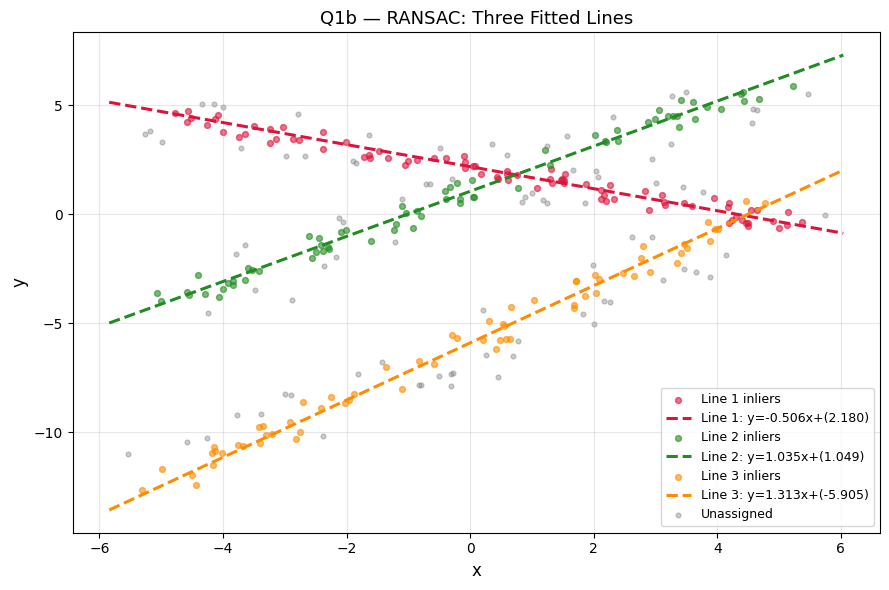


Plot saved as q1b_ransac_3lines.png

  RANSAC Results Summary — All Three Lines
  Line              a          b          c      slope  intercept
------------------------------------------------------------
  Line 1       0.4512     0.8924    -1.9458    -0.5056     2.1804
  Line 2       0.7191    -0.6949     0.7287     1.0348     1.0486
  Line 3      -0.7955     0.6060     3.5787     1.3126    -5.9053


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and flatten all data
D = np.genfromtxt("/content/Assignment 2/lines.csv", delimiter=",", skip_header=1)

X_cols = D[:, :3]
Y_cols = D[:, 3:]

# Flatten: stack all 3 x-columns and 3 y-columns into single arrays
# This gives us 300 points total (100 rows × 3 columns)
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points = np.column_stack([X_all, Y_all])  # shape: (300, 2)

# 2. TLS helper: fit a line to a set of points using SVD
def fit_line_tls(pts):
    """
    Fit a line ax + by + c = 0 to pts using Total Least Squares (SVD).
    Returns (a, b, c) with a²+b²=1.
    """
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    A = pts - np.array([cx, cy])              # centre the points
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1]                             # normal = last right singular vector
    c = -(a * cx + b * cy)                    # recover offset
    return a, b, c

# 3. Perpendicular distance from points to line ax+by+c=0
def perp_distance(pts, a, b, c):
    """
    Returns perpendicular distance of each point in pts from line ax+by+c=0.
    Since a²+b²=1 (TLS guarantees this), denominator = 1.
    """
    return np.abs(a * pts[:, 0] + b * pts[:, 1] + c) / np.sqrt(a**2 + b**2)

# 4. RANSAC line fitting
def ransac_line(pts, n_iter=1000, threshold=0.5, min_inliers=20):
    """
    Fit a line to pts using RANSAC.

    Parameters:
        pts        : (N, 2) array of 2D points
        n_iter     : number of RANSAC iterations
        threshold  : max perpendicular distance to be called an inlier
        min_inliers: minimum inliers to accept a model

    Returns:
        best_line    : (a, b, c) of best fitted line
        best_mask    : boolean mask of inliers
    """
    best_inlier_count = 0
    best_line  = None
    best_mask  = None
    n = len(pts)

    for _ in range(n_iter):
        # Step 1: Randomly sample 2 points (minimum to define a line)
        idx = np.random.choice(n, 2, replace=False)
        sample = pts[idx]

        # Step 2: Fit a line to the 2 sampled points
        # With only 2 points, TLS = direct line through them
        # We use fit_line_tls which works for any number ≥ 2
        try:
            a, b, c = fit_line_tls(sample)
        except Exception:
            continue

        # Step 3: Compute perpendicular distance of ALL points to this line
        dists = perp_distance(pts, a, b, c)

        # Step 4: Count inliers (points within threshold distance)
        inlier_mask = dists < threshold
        inlier_count = inlier_mask.sum()

        # Step 5: Save if this is the best model so far
        if inlier_count > best_inlier_count and inlier_count >= min_inliers:
            best_inlier_count = inlier_count
            best_line  = (a, b, c)
            best_mask  = inlier_mask

    # Step 6: Refit using ALL inliers (not just the 2 random points)
    if best_mask is not None and best_mask.sum() >= 2:
        a, b, c = fit_line_tls(pts[best_mask])
        best_line = (a, b, c)
        # Recompute final inlier mask with the refined line
        dists = perp_distance(pts, a, b, c)
        best_mask = dists < threshold

    return best_line, best_mask

# 5. Iterative RANSAC: find 3 lines one by one
np.random.seed(42)   # for reproducibility

remaining_pts   = points.copy()
remaining_idx   = np.arange(len(points))   # track original indices

lines   = []    # will store (a, b, c) for each found line
masks   = []    # will store inlier masks (in original 300-point indexing)
colors  = ['crimson', 'forestgreen', 'darkorange']
labels  = ['Line 1', 'Line 2', 'Line 3']

for i in range(3):
    print(f"\n--- RANSAC iteration {i+1}: fitting line {i+1} ---")
    print(f"  Points remaining: {len(remaining_pts)}")

    # Run RANSAC on whatever points are left
    line, mask = ransac_line(remaining_pts, n_iter=2000, threshold=0.5, min_inliers=20)

    if line is None:
        print(f"  WARNING: RANSAC failed to find a line!")
        break

    a, b, c = line
    slope     = -a / b
    intercept = -c / b

    print(f"  Found: {a:.4f}·x + {b:.4f}·y + {c:.4f} = 0")
    print(f"  Slope-intercept: y = {slope:.4f}·x + ({intercept:.4f})")
    print(f"  Inliers: {mask.sum()} / {len(remaining_pts)}")

    # Store the line and map inlier mask back to original indices
    lines.append(line)
    global_mask = np.zeros(len(points), dtype=bool)
    global_mask[remaining_idx[mask]] = True
    masks.append(global_mask)

    # MASK the consensus: remove inliers from remaining points
    # This is the key step: "mask the consensus and run again"
    remaining_idx = remaining_idx[~mask]
    remaining_pts = points[remaining_idx]

# 6. Visualize all three fitted lines
fig, ax = plt.subplots(figsize=(9, 6))

x_range = np.linspace(points[:, 0].min() - 0.3, points[:, 0].max() + 0.3, 400)

for i, (line, mask) in enumerate(zip(lines, masks)):
    a, b, c = line
    slope     = -a / b
    intercept = -c / b

    # Scatter the inlier points for this line
    ax.scatter(points[mask, 0], points[mask, 1],
               color=colors[i], s=18, alpha=0.6, label=f'{labels[i]} inliers')

    # Draw the fitted line
    y_range = slope * x_range + intercept
    ax.plot(x_range, y_range, color=colors[i], linewidth=2.2,
            linestyle='--', label=f'{labels[i]}: y={slope:.3f}x+({intercept:.3f})')

# Any points not assigned to any line (outliers of all 3)
all_assigned = np.any(np.column_stack(masks), axis=1)
unassigned   = ~all_assigned
if unassigned.sum() > 0:
    ax.scatter(points[unassigned, 0], points[unassigned, 1],
               color='grey', s=12, alpha=0.4, label='Unassigned')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('Q1b — RANSAC: Three Fitted Lines', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('q1b_ransac_3lines.png', dpi=150)
plt.show()
print("\nPlot saved as q1b_ransac_3lines.png")

# 7. Summary table
print("\n" + "=" * 60)
print("  RANSAC Results Summary — All Three Lines")
print("=" * 60)
print(f"  {'Line':<8} {'a':>10} {'b':>10} {'c':>10} {'slope':>10} {'intercept':>10}")
print("-" * 60)
for i, (line, mask) in enumerate(zip(lines, masks)):
    a, b, c = line
    slope     = -a / b
    intercept = -c / b
    print(f"  {labels[i]:<8} {a:>10.4f} {b:>10.4f} {c:>10.4f} {slope:>10.4f} {intercept:>10.4f}")
print("=" * 60)